In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import GEOparse

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [24]:
# Load the counts

counts_path = r"C:\Users\Tyler\Bellevue\DSC630\GSE121212_readcount.txt"
counts = pd.read_csv(counts_path, sep="\t")
print("Raw counts shape:", counts.shape)
counts.head()

Raw counts shape: (31364, 148)


,Unnamed: 0,AD_004_lesional,AD_004_non-lesional,AD_005_lesional,AD_005_non-lesional,AD_006_lesional,AD_006_non-lesional,AD_007_lesional,AD_007_non-lesional,AD_009_lesional,...,AD_033_chronic_lesion,AD_034_non-lesional,AD_034_chronic_lesion,AD_032_chronic_lesion,AD_035_non-lesional,AD_035_chronic_lesion,AD_036_non-lesional,AD_036_chronic_lesion,AD_037_non-lesional,AD_037_chronic_lesion
0,5S_rRNA,0,3,9,12,2,3,6,4,2,...,1,2,3,3,3,4,3,5,6,2
1,7SK,9,6,25,25,7,8,9,8,6,...,3,8,2,5,12,5,7,5,8,3
2,A1BG,2,0,4,3,1,1,0,0,4,...,1,1,2,0,1,2,0,0,1,1
3,A1BG-AS1,5,0,11,8,7,8,13,2,6,...,4,0,7,7,4,4,10,13,8,4
4,A1CF,2,3,2,8,1,2,0,5,1,...,3,0,1,0,0,2,0,0,1,0


The output confirms that the RNA-seq read count matrix was loaded successfully. The raw dataset contains 31,364 rows and 148 columns, which indicates one gene identifier column and 147 sample columns. The preview shows that the rows represent genes and the columns epresent individual biopsy samples, which is the expected structure for transcriptomic count data. This confirms that the dataset was imported in a usable format for downstream processing and modeling. 

In [25]:
# Clean the matrix

possible_gene_cols = [c for c in counts.columns if c.lower() in ["gene", "genes", "symbol", "gene_symbol", "ensembl", "id"]]

if possible_gene_cols:
    gene_col = possible_gene_cols[0]
else:
    gene_col = counts.columns[0]

print("Using gene column:", gene_col)

counts = counts.rename(columns={gene_col: "gene_id"})
counts = counts.drop_duplicates(subset="gene_id")
counts = counts.set_index("gene_id")

counts = counts.apply(pd.to_numeric, errors="coerce")
counts = counts.dropna(axis=1, how="all")

print("Cleaned counts shape:", counts.shape)
counts.iloc[:5, :5]

Using gene column: Unnamed: 0
Cleaned counts shape: (31362, 147)


,AD_004_lesional,AD_004_non-lesional,AD_005_lesional,AD_005_non-lesional,AD_006_lesional
gene_id,,,,,
5S_rRNA,0,3,9,12,2
7SK,9,6,25,25,7
A1BG,2,0,4,3,1
A1BG-AS1,5,0,11,8,7
A1CF,2,3,2,8,1


In this step, the first column, Unnamed: 0, was identified as the gene identifier column and renamed to improve readability. After removing duplicate genes and keeping only numeric expression values, the cleaned dataset contained 31,362 genes across 147 samples. Only a small number of rows were removed during cleaning, which suggests the processed GEO file was already well structured. At this point, the dataset was ready to be matched with GEO metadata and filtered to the target disease groups.

In [26]:
# Load GEO metadata
gse = GEOparse.get_GEO("GSE121212", destdir=r"C:\Users\Tyler\Bellevue\DSC630")
print("Number of GSM samples:", len(gse.gsms))

17-May-2026 00:12:08 DEBUG utils - Directory C:\Users\Tyler\Bellevue\DSC630 already exists. Skipping.
17-May-2026 00:12:08 INFO GEOparse - File already exist: using local version.
17-May-2026 00:12:08 INFO GEOparse - Parsing C:\Users\Tyler\Bellevue\DSC630\GSE121212_family.soft.gz: 
17-May-2026 00:12:08 DEBUG GEOparse - DATABASE: GeoMiame
17-May-2026 00:12:08 DEBUG GEOparse - SERIES: GSE121212
17-May-2026 00:12:08 DEBUG GEOparse - PLATFORM: GPL16791
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427868
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427869
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427870
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427871
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427872
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427873
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427874
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427875
17-May-2026 00:12:08 DEBUG GEOparse - SAMPLE: GSM3427876
17-May-2026 00:12:08 DEBUG GEOpars

Number of GSM samples: 147


The GEO metadata contained 147 GSM samples, which matches the 147 sample columns in the cleaned count matrix. This confirms that the metadata and expression data are aligned at the full dataset level. The sample titles clearly identify whether each sample is healthy, lesional, or non-lesional, which is important because these labels were used to define the final target classes for the classification task.

In [27]:
# Build metadata table

meta_rows = []

for gsm_id, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [""])[0]
    source = gsm.metadata.get("source_name_ch1", [""])[0]

    meta_rows.append({
        "gsm_id": gsm_id,
        "title": title,
        "source": source
    })

meta = pd.DataFrame(meta_rows)
meta.head(10)

,gsm_id,title,source
0,GSM3427868,AD_004_lesional,skin biopsy
1,GSM3427869,AD_004_non-lesional,skin biopsy
2,GSM3427870,AD_005_lesional,skin biopsy
3,GSM3427871,AD_005_non-lesional,skin biopsy
4,GSM3427872,AD_006_lesional,skin biopsy
5,GSM3427873,AD_006_non-lesional,skin biopsy
6,GSM3427874,AD_007_lesional,skin biopsy
7,GSM3427875,AD_007_non-lesional,skin biopsy
8,GSM3427876,AD_009_lesional,skin biopsy
9,GSM3427877,AD_009_non-lesional,skin biopsy


In [28]:
# Assign class labels
def assign_group(title):
    t = str(title).lower()

    if "ctrl_" in t and "healthy" in t:
        return "Healthy"

    if "pso_" in t and "lesional" in t and "non-lesional" not in t:
        return "Psoriasis"

    if "ad_" in t and ("lesional" in t or "chronic_lesion" in t) and "non-lesional" not in t:
        return "Atopic_Dermatitis"

    return None

meta["group"] = meta["title"].apply(assign_group)
meta_kept = meta[meta["group"].notna()].copy()

print(meta_kept["group"].value_counts())
meta_kept.head(20)

group
Healthy              38
Psoriasis            28
Atopic_Dermatitis    27
Name: count, dtype: int64


,gsm_id,title,source,group
0,GSM3427868,AD_004_lesional,skin biopsy,Atopic_Dermatitis
2,GSM3427870,AD_005_lesional,skin biopsy,Atopic_Dermatitis
4,GSM3427872,AD_006_lesional,skin biopsy,Atopic_Dermatitis
6,GSM3427874,AD_007_lesional,skin biopsy,Atopic_Dermatitis
8,GSM3427876,AD_009_lesional,skin biopsy,Atopic_Dermatitis
10,GSM3427878,AD_011_lesional,skin biopsy,Atopic_Dermatitis
12,GSM3427880,AD_014_lesional,skin biopsy,Atopic_Dermatitis
14,GSM3427882,AD_016_lesional,skin biopsy,Atopic_Dermatitis
16,GSM3427884,AD_017_lesional,skin biopsy,Atopic_Dermatitis
18,GSM3427886,AD_019_lesional,skin biopsy,Atopic_Dermatitis


After applying the class definitions, the dataset was reduced to 38 healthy controls, 28 psoriasis samples, and 27 atopic dermatitis samples. This creates a workable multiclass classification problem with reasonably balanced class sizes. Although the classes are not perfectly equal, the imbalance is modest enough that multiclass modeling remains appropriate, especially when supported by macro-averaged evaluation metrics.

In [29]:
# Match metadata to expression columns

count_cols = counts.columns.tolist()

gsm_matches = [gsm for gsm in meta_kept["gsm_id"] if gsm in count_cols]
title_matches = [title for title in meta_kept["title"] if title in count_cols]

print("Matched GSM columns:", len(gsm_matches))
print("Matched title columns:", len(title_matches))

Matched GSM columns: 0
Matched title columns: 93


In [30]:
# Build final expression matrix

if len(gsm_matches) >= len(title_matches) and len(gsm_matches) > 0:
    meta_final = meta_kept[meta_kept["gsm_id"].isin(gsm_matches)].copy()
    meta_final["expr_col"] = meta_final["gsm_id"]
elif len(title_matches) > 0:
    meta_final = meta_kept[meta_kept["title"].isin(title_matches)].copy()
    meta_final["expr_col"] = meta_final["title"]
else:
    raise ValueError("Could not match metadata to expression columns.")

expr = counts[meta_final["expr_col"].tolist()].T
expr.index.name = "sample_id"

meta_final = meta_final.set_index("expr_col").loc[expr.index].reset_index()
y = meta_final["group"].values

print("Expression matrix shape:", expr.shape)
print(pd.Series(y).value_counts())
expr.iloc[:5, :5]

Expression matrix shape: (93, 31362)
Healthy              38
Psoriasis            28
Atopic_Dermatitis    27
Name: count, dtype: int64


gene_id,5S_rRNA,7SK,A1BG,A1BG-AS1,A1CF
sample_id,,,,,
AD_004_lesional,0,9,2,5,2
AD_005_lesional,9,25,4,11,2
AD_006_lesional,2,7,1,7,1
AD_007_lesional,6,9,0,13,0
AD_009_lesional,2,6,4,6,1


The metadata matched the count matrix using the sample titles rather than GSM identifiers, resulting in 93 usable samples for the final analysis. The resulting expression matrix contains 93 samples and 31,362 gene features, which is a typical high-dimensional bioinformatics dataset where the number of predictors greatly exceeds the number of observations. This supports the original project plan of using models that can handle wide data, such as support vector machines, and also reinforces the need for feature reduction before modeling.

In [31]:
# Encode labels and split first
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X = expr.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", list(le.classes_))

Train shape: (69, 31362)
Test shape: (24, 31362)
Classes: ['Atopic_Dermatitis', 'Healthy', 'Psoriasis']


The dataset was split into training and testing sets before feature selection and model fitting, which helps prevent information leakage. The training set contained 69 samples, while the test set contained 24 samples, with stratification used to preserve the class proportions across both sets. This is an important step because it ensures that model evaluation is based on truly unseen data rather than data that influenced preprocessing decisions.

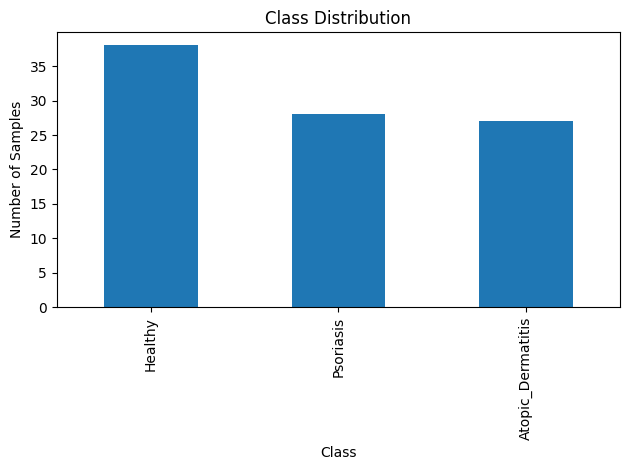

In [32]:
# Class distribution plot
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

The class distribution plot shows that the final dataset is reasonably balanced, with healthy controls being the largest group and psoriasis and atopic dermatitis represented at similar levels. This balance is favorable for multiclass classification because no single class overwhelmingly dominates the dataset. Even so, using macro-averaged precision, recall, and F1-score remains important to make sure model performance is assessed fairly across all three classes.

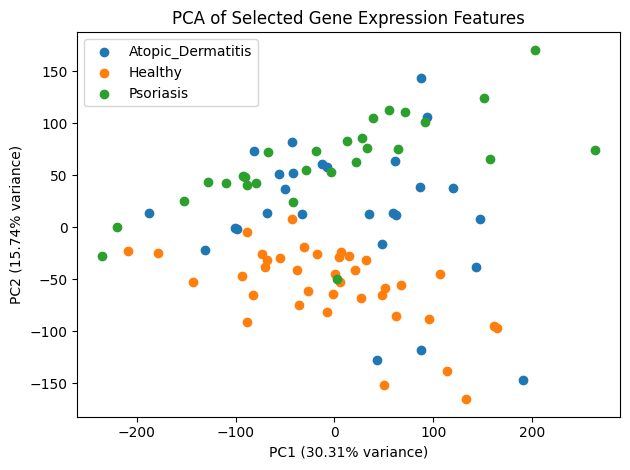

In [33]:
# PCA plot for visualization only
scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_vis)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y
})

for cls in plot_df["Class"].unique():
    subset = plot_df[plot_df["Class"] == cls]
    plt.scatter(subset["PC1"], subset["PC2"], label=cls)

plt.title("PCA of Selected Gene Expression Features")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.legend()
plt.tight_layout()
plt.show()

The PCA plot shows that the selected disease groups have meaningful separation in reduced-dimensional space. In this visualization, PC1 explains 30.31% of the variance and PC2 explains 15.74%, indicating that the first two components capture a substantial portion of the variation in the gene expression data. Healthy controls appear especially distinct from the disease groups, while psoriasis and atopic dermatitis also show clustering patterns with some overlap. This supports the idea that the transcriptomic data contain useful signal for classification, while also suggesting that the two inflammatory diseases may be more similar to each other than either is to healthy tissue.

In [35]:
# Logistic regression
logreg_pipe = Pipeline([
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("feature_select", SelectKBest(score_func=f_classif, k=1000)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

logreg_pipe.fit(X_train, y_train)
logreg_pred = logreg_pipe.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, logreg_pred, target_names=le.classes_))

Logistic Regression Accuracy: 1.0

Classification Report:

                   precision    recall  f1-score   support

Atopic_Dermatitis       1.00      1.00      1.00         7
          Healthy       1.00      1.00      1.00        10
        Psoriasis       1.00      1.00      1.00         7

         accuracy                           1.00        24
        macro avg       1.00      1.00      1.00        24
     weighted avg       1.00      1.00      1.00        24



The logistic regression model achieved 100% accuracy on the held-out test set, with perfect precision, recall, and F1-scores for all three classes. These results indicate that the selected features provide very strong discriminatory signal for this classification problem. However, because the sample size is still relatively small and the feature space remains large even after reduction, the perfect test performance should be interpreted cautiously. Even so, the results strongly suggest that gene expression profiles in this dataset are highly informative for distinguishing the selected skin disease states.

In [37]:
# SVM pipeline
svm_pipe = Pipeline([
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("feature_select", SelectKBest(score_func=f_classif, k=1000)),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear"))
])

svm_pipe.fit(X_train, y_train)
svm_pred = svm_pipe.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred, target_names=le.classes_))

SVM Accuracy: 0.9583333333333334

Classification Report:

                   precision    recall  f1-score   support

Atopic_Dermatitis       1.00      0.86      0.92         7
          Healthy       1.00      1.00      1.00        10
        Psoriasis       0.88      1.00      0.93         7

         accuracy                           0.96        24
        macro avg       0.96      0.95      0.95        24
     weighted avg       0.96      0.96      0.96        24



The support vector machine achieved 95.83% accuracy on the test set, with strong class-specific performance across all three groups. Healthy samples were classified perfectly, psoriasis had perfect recall, and only one atopic dermatitis sample was misclassified as psoriasis. This is a realistic and biologically plausible error pattern, since psoriasis and atopic dermatitis are both inflammatory skin conditions and may share some overlapping transcriptomic characteristics. Overall, the SVM results provide strong support for the idea that RNA-seq data can be used to classify these disease states.

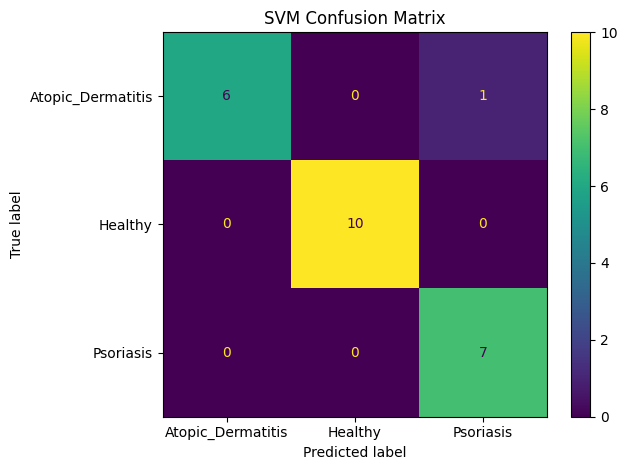

In [39]:
# Confustion matrix

cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the SVM classified all healthy and psoriasis samples correctly in the test set, while one atopic dermatitis sample was predicted as psoriasis. This suggests that healthy controls may be the easiest class to separate, while the two inflammatory disease groups may be somewhat more difficult to distinguish from one another. That interpretation is consistent with the biology of the problem, since both psoriasis and atopic dermatitis involve inflammatory pathways and may share some molecular overlap.

In [40]:
# Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_cv_pipe = Pipeline([
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("feature_select", SelectKBest(score_func=f_classif, k=1000)),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear"))
])

cv_scores = cross_val_score(svm_cv_pipe, X, y_encoded, cv=cv, scoring="accuracy")

print("SVM Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

SVM Cross-Validation Accuracy Scores: [0.89473684 0.94736842 0.94736842 0.94444444 0.94444444]
Mean CV Accuracy: 0.935672514619883
Std CV Accuracy: 0.020509564814912475


The 5-fold cross-validation results for the SVM were consistently strong, with accuracy scores ranging from 0.8947 to 0.9474, a mean accuracy of 0.9357, and a standard deviation of 0.0205. These results suggest that the model is learning a stable signal rather than relying on one especially favorable split of the data. The relatively low standard deviation also indicates that performance was fairly consistent across folds, which strengthens confidence in the overall classification results.

In [42]:
# How many features survived in training set

# Fit just once so we can inspect selected features
svm_pipe.fit(X_train, y_train)

variance_step = svm_pipe.named_steps["variance_filter"]
feature_step = svm_pipe.named_steps["feature_select"]

X_train_vf = variance_step.transform(X_train)
print("Features after variance filtering on training set:", X_train_vf.shape[1])

support_mask = feature_step.get_support()
print("Features selected by SelectKBest:", support_mask.sum())

Features after variance filtering on training set: 31362
Features selected by SelectKBest: 1000


After fitting the preprocessing pipeline on the training data, the variance filtering step retained all 31,362 genes, indicating that no features had zero variance within the training set. The SelectKBest step then reduced the data to 1,000 selected features, which substantially lowered dimensionality while preserving the strongest class-related signals for modeling. This feature reduction step was especially important in this project because the original dataset was extremely wide relative to the number of samples, creating a high risk of overfitting without further filtering.